# Assignment 8 — Linear Regression on Taxi Trip Pricing

## Topic Explanation

### What is Regression?
**Regression** is a supervised machine learning task that predicts a **continuous numeric value** based on input features. Examples: house prices, temperature, **taxi trip price** (this assignment).

### What is Linear Regression?
**Linear Regression** fits a straight line (or hyperplane) through data such that the average squared distance between predictions and actual values is minimized.

#### Simple Linear Regression — One Predictor
> **y = b₀ + b₁·x**

- **y** = target (Trip_Price)
- **x** = single feature (e.g., Trip_Distance_km)
- **b₀** = intercept; **b₁** = slope

#### Multiple Linear Regression — Many Predictors
> **y = b₀ + b₁·x₁ + b₂·x₂ + ... + bₙ·xₙ**

Each `bᵢ` is the contribution of feature xᵢ.

### One-Hot Encoding for Categorical Features
Our dataset has categorical features (Time_of_Day, Day_of_Week, Traffic_Conditions, Weather). We use `pd.get_dummies(drop_first=True)` to convert them into 0/1 columns.

### How Does the Model Learn?
The model finds coefficients that minimize **Mean Squared Error (MSE)**:
> MSE = (1/n) · Σ(yᵢ − ŷᵢ)²

Sklearn's `LinearRegression` uses the closed-form **Normal Equation**: `b = (XᵀX)⁻¹Xᵀy`.

### Evaluation Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| **MSE** | (1/n)·Σ(y−ŷ)² | Average squared error |
| **RMSE** | √MSE | Same units as y |
| **MAE** | (1/n)·Σ\|y−ŷ\| | Average absolute error |
| **R²** | 1 − SSres/SStot | Fraction of variance explained |

**The main goal of this assignment:** **Compare the MSE of Simple LR and Multiple LR.** Multiple LR almost always wins because trip price depends on multiple factors (distance, time spent, base fare, rates, traffic, weather).

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — ML utilities
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Dataset

In [2]:
# Load the taxi trip pricing dataset
df = pd.read_csv('taxi_trip_pricing.csv')
print("Shape:", df.shape)
df.head()

Shape: (300, 11)


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,14.68,Night,Weekday,3,Medium,Clear,3.56,1.98,0.49,95.0,80.92
1,48.63,Afternoon,Weekend,1,Medium,Clear,4.43,1.87,0.34,111.0,133.93
2,28.15,Morning,Weekday,1,Low,Snow,3.28,0.54,0.39,48.0,36.55
3,18.98,Evening,Weekend,4,High,Clear,4.10,1.66,0.28,63.0,56.29
4,44.49,Afternoon,Weekend,3,Low,Clear,3.30,0.67,0.12,47.0,37.75


In [3]:
# Inspect column types and check for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       300 non-null    float64
 1   Time_of_Day            300 non-null    str    
 2   Day_of_Week            300 non-null    str    
 3   Passenger_Count        300 non-null    int64  
 4   Traffic_Conditions     300 non-null    str    
 5   Weather                300 non-null    str    
 6   Base_Fare              300 non-null    float64
 7   Per_Km_Rate            300 non-null    float64
 8   Per_Minute_Rate        300 non-null    float64
 9   Trip_Duration_Minutes  300 non-null    float64
 10  Trip_Price             300 non-null    float64
dtypes: float64(6), int64(1), str(4)
memory usage: 25.9 KB


In [4]:
# Summary statistics
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,25.850333,2.580000,3.435533,1.266233,0.299800,60.090000,54.193167
std,14.875413,1.120022,0.835341,0.442323,0.115205,33.984089,28.150260
min,0.960000,1.000000,2.020000,0.500000,0.100000,5.000000,6.680000
25%,12.640000,2.000000,2.677500,0.877500,0.200000,32.000000,33.915000
50%,25.945000,3.000000,3.420000,1.290000,0.310000,58.000000,48.125000
75%,39.485000,4.000000,4.150000,1.650000,0.400000,91.000000,72.452500
max,49.890000,4.000000,5.000000,2.000000,0.500000,120.000000,150.110000


## Step 3: Identify Predictor and Target Variables

- **Predictors (X)** — all features that influence the trip price
- **Target (y)** — `Trip_Price`

In [5]:
predictors = [c for c in df.columns if c != 'Trip_Price']

print("Predictor variables (X):")
for p in predictors:
    print(f"  - {p}  ({'numeric' if df[p].dtype != 'object' else 'categorical'})")

print("\nTarget variable (y): Trip_Price")

Predictor variables (X):
  - Trip_Distance_km  (numeric)
  - Time_of_Day  (numeric)
  - Day_of_Week  (numeric)
  - Passenger_Count  (numeric)
  - Traffic_Conditions  (numeric)
  - Weather  (numeric)
  - Base_Fare  (numeric)
  - Per_Km_Rate  (numeric)
  - Per_Minute_Rate  (numeric)
  - Trip_Duration_Minutes  (numeric)

Target variable (y): Trip_Price


## Step 4: Visualize Relationships

For numeric predictors → scatter plots. For categorical → boxplots.

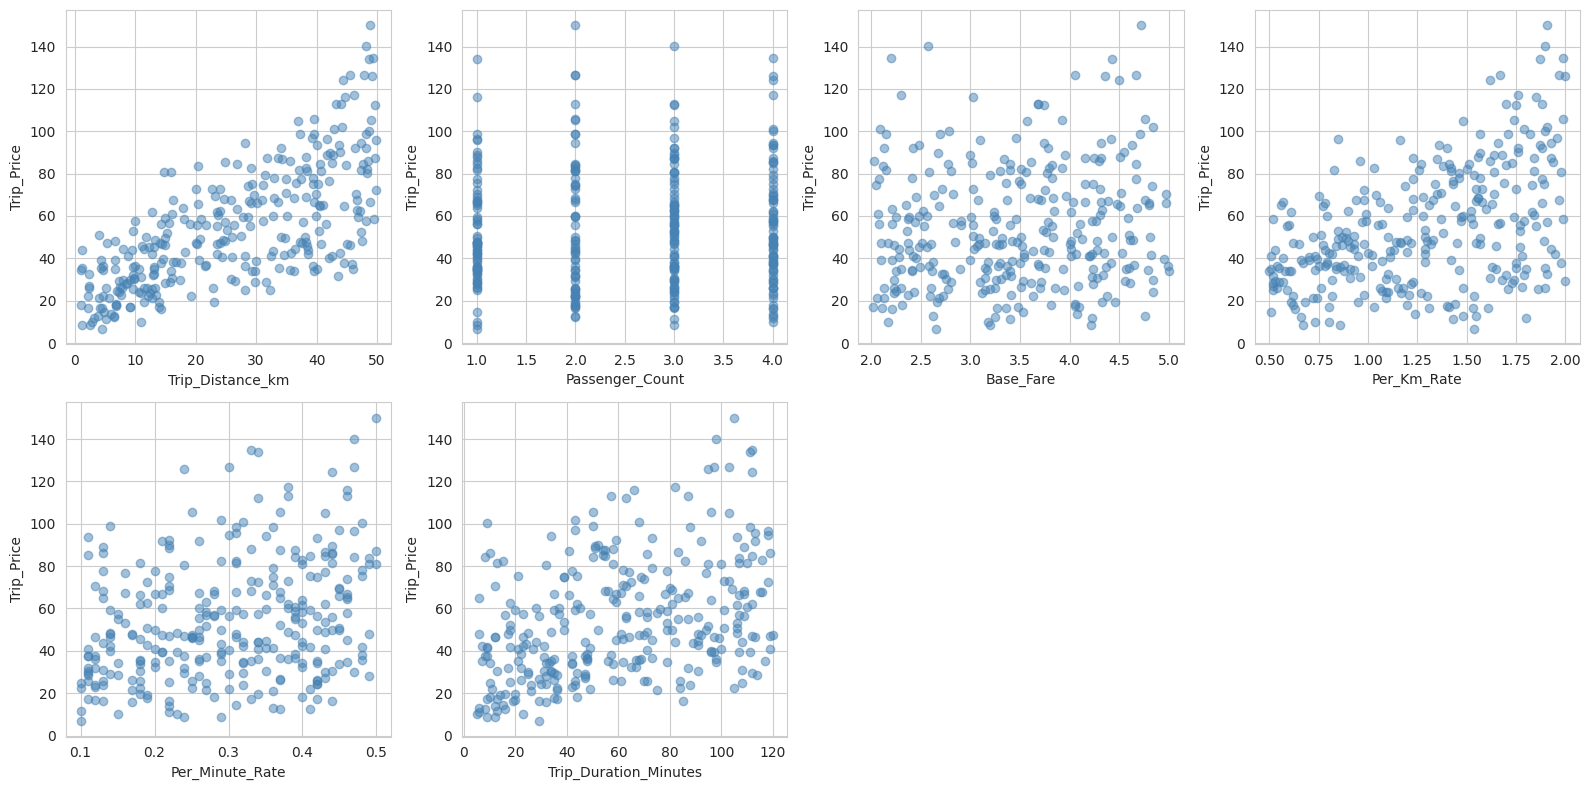

In [6]:
# Numeric predictors: scatter plot vs target
numeric_cols = df[predictors].select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.scatter(df[col], df['Trip_Price'], alpha=0.5, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('Trip_Price')

# Hide unused subplot if numeric_cols < 8
for j in range(len(numeric_cols), 8):
    axes.flatten()[j].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
# Correlation of numeric predictors with target
corr = df[numeric_cols + ['Trip_Price']].corr()['Trip_Price'].drop('Trip_Price').sort_values(ascending=False)
print("Correlation of numeric predictors with Trip_Price:")
print(corr.round(4))

Correlation of numeric predictors with Trip_Price:
Trip_Distance_km         0.7112
Per_Km_Rate              0.4774
Trip_Duration_Minutes    0.4034
Per_Minute_Rate          0.2943
Base_Fare                0.1135
Passenger_Count          0.0267
Name: Trip_Price, dtype: float64


## Step 5: One-Hot Encode Categoricals + 80/20 Split

In [8]:
# One-hot encode all categorical columns; drop_first=True to avoid dummy trap
df_encoded = pd.get_dummies(df, drop_first=True)

print("Shape before encoding:", df.shape)
print("Shape after encoding :", df_encoded.shape)
print("\nColumns after encoding:")
print(df_encoded.columns.tolist())

Shape before encoding: (300, 11)
Shape after encoding : (300, 15)

Columns after encoding:
['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price', 'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night', 'Day_of_Week_Weekend', 'Traffic_Conditions_Low', 'Traffic_Conditions_Medium', 'Weather_Rain', 'Weather_Snow']


In [9]:
# X = all features, y = target
X = df_encoded.drop('Trip_Price', axis=1)
y = df_encoded['Trip_Price']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)

Train shape: (240, 14)  | Test shape: (60, 14)


## Step 6: Simple Linear Regression (Distance Only)

We use `Trip_Distance_km` as the single predictor.

In [10]:
simple = LinearRegression()
simple.fit(X_train[['Trip_Distance_km']], y_train)

print(f"Simple LR equation:")
print(f"  Trip_Price = {simple.intercept_:.2f} + {simple.coef_[0]:.2f} × Trip_Distance_km")

Simple LR equation:
  Trip_Price = 18.03 + 1.37 × Trip_Distance_km


In [11]:
# Predict on test set and compute metrics
y_pred_simple = simple.predict(X_test[['Trip_Distance_km']])

mse_simple  = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
mae_simple  = mean_absolute_error(y_test, y_pred_simple)
r2_simple   = r2_score(y_test, y_pred_simple)

print("Simple LR — Test Set Performance:")
print(f"  MSE  = {mse_simple:.4f}")
print(f"  RMSE = {rmse_simple:.4f}")
print(f"  MAE  = {mae_simple:.4f}")
print(f"  R²   = {r2_simple:.4f}  ({r2_simple*100:.2f}%)")

Simple LR — Test Set Performance:
  MSE  = 442.6590
  RMSE = 21.0395
  MAE  = 16.9232
  R²   = 0.3846  (38.46%)


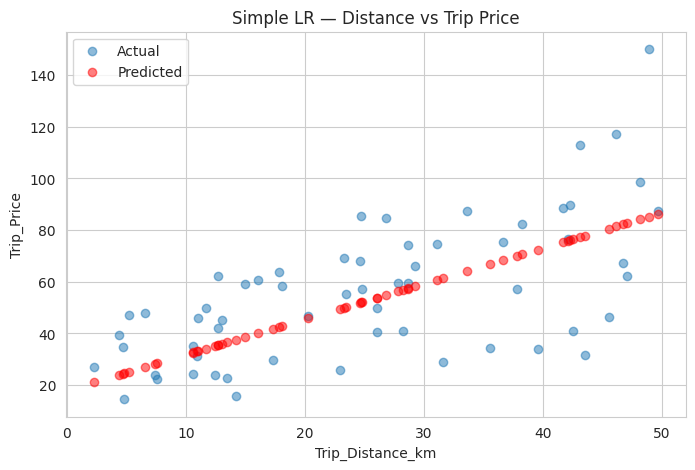

In [12]:
# Plot the regression line over test data
plt.figure(figsize=(8, 5))
plt.scatter(X_test['Trip_Distance_km'], y_test, alpha=0.5, label='Actual')
plt.scatter(X_test['Trip_Distance_km'], y_pred_simple, alpha=0.5, color='red', label='Predicted')
plt.xlabel('Trip_Distance_km')
plt.ylabel('Trip_Price')
plt.title('Simple LR — Distance vs Trip Price')
plt.legend()
plt.show()

## Step 7: Multiple Linear Regression (All Features)

Now use ALL features including categorical dummies.

In [13]:
multi = LinearRegression()
multi.fit(X_train, y_train)

# Print coefficients sorted by magnitude
coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': multi.coef_.round(4)
}).sort_values('Coefficient', ascending=False)

print("Multiple LR Coefficients:")
print(coefs)
print(f"\nIntercept: {multi.intercept_:.4f}")

Multiple LR Coefficients:
                      Feature  Coefficient
4             Per_Minute_Rate      64.5441
3                 Per_Km_Rate      25.9334
8           Time_of_Day_Night       1.3457
0            Trip_Distance_km       1.3294
6         Time_of_Day_Evening       1.3164
2                   Base_Fare       1.1433
1             Passenger_Count       1.0450
9         Day_of_Week_Weekend       0.6108
13               Weather_Snow       0.5588
5       Trip_Duration_Minutes       0.2991
7         Time_of_Day_Morning      -0.4717
10     Traffic_Conditions_Low      -0.6030
12               Weather_Rain      -0.6788
11  Traffic_Conditions_Medium      -1.0329

Intercept: -57.3751


In [14]:
# Predict and evaluate
y_pred_multi = multi.predict(X_test)

mse_multi  = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
mae_multi  = mean_absolute_error(y_test, y_pred_multi)
r2_multi   = r2_score(y_test, y_pred_multi)

print("Multiple LR — Test Set Performance:")
print(f"  MSE  = {mse_multi:.4f}")
print(f"  RMSE = {rmse_multi:.4f}")
print(f"  MAE  = {mae_multi:.4f}")
print(f"  R²   = {r2_multi:.4f}  ({r2_multi*100:.2f}%)")

Multiple LR — Test Set Performance:
  MSE  = 71.5129
  RMSE = 8.4565
  MAE  = 6.5394
  R²   = 0.9006  (90.06%)


## Step 8: Compare MSE of Simple vs Multiple LR ⭐

This is the **main objective** of the assignment.

In [15]:
comparison = pd.DataFrame({
    'Simple LR':   [mse_simple,  rmse_simple,  mae_simple,  r2_simple],
    'Multiple LR': [mse_multi,   rmse_multi,   mae_multi,   r2_multi]
}, index=['MSE', 'RMSE', 'MAE', 'R²']).round(4)

print("Simple vs Multiple Linear Regression:")
print(comparison)

print(f"\n>>> MSE Simple   = {mse_simple:.4f}")
print(f">>> MSE Multiple = {mse_multi:.4f}")
print(f">>> Improvement  = {((mse_simple - mse_multi)/mse_simple)*100:.2f}% reduction in MSE")

Simple vs Multiple Linear Regression:
      Simple LR  Multiple LR
MSE    442.6590      71.5129
RMSE    21.0395       8.4565
MAE     16.9232       6.5394
R²       0.3846       0.9006

>>> MSE Simple   = 442.6590
>>> MSE Multiple = 71.5129
>>> Improvement  = 83.84% reduction in MSE


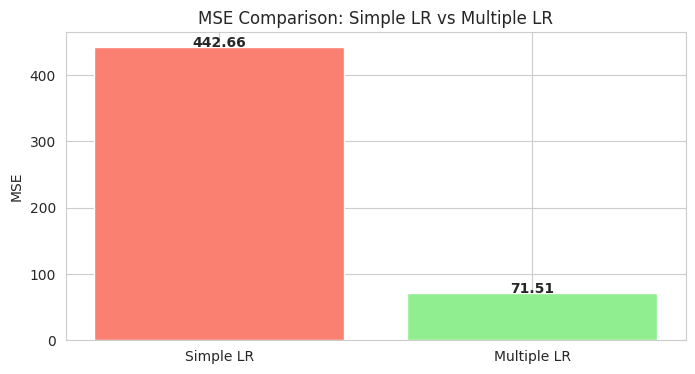

In [16]:
# Visual comparison via bar chart
plt.figure(figsize=(8, 4))
plt.bar(['Simple LR', 'Multiple LR'], [mse_simple, mse_multi],
        color=['salmon', 'lightgreen'])
plt.ylabel('MSE')
plt.title('MSE Comparison: Simple LR vs Multiple LR')
for i, v in enumerate([mse_simple, mse_multi]):
    plt.text(i, v + 0.5, f'{v:.2f}', ha='center', fontweight='bold')
plt.show()

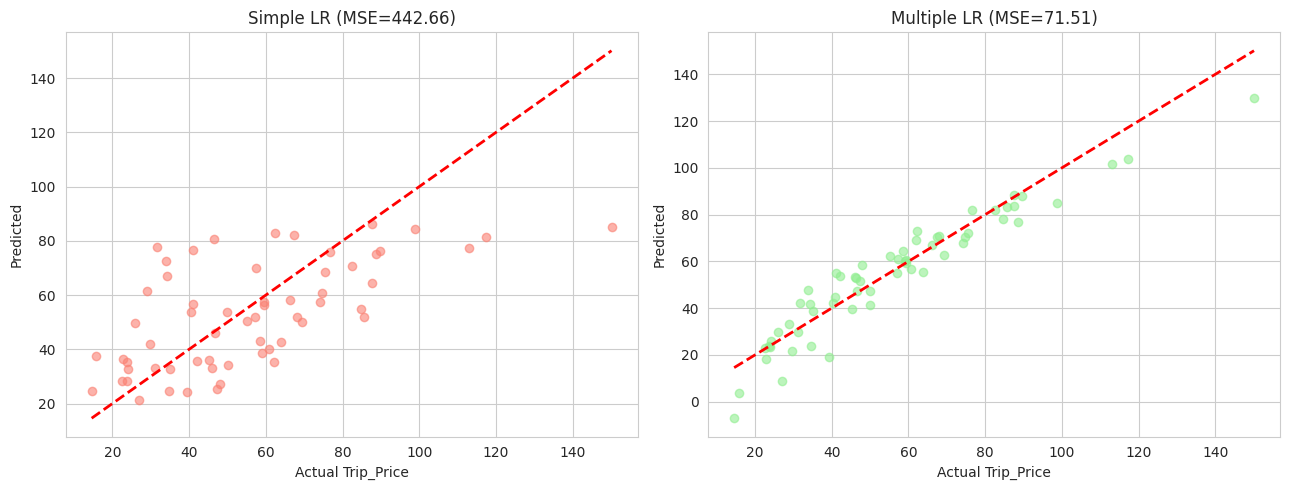

In [17]:
# Actual vs Predicted plot for both models
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].scatter(y_test, y_pred_simple, alpha=0.6, color='salmon')
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[0].set_xlabel('Actual Trip_Price'); ax[0].set_ylabel('Predicted')
ax[0].set_title(f'Simple LR (MSE={mse_simple:.2f})')

ax[1].scatter(y_test, y_pred_multi, alpha=0.6, color='lightgreen')
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[1].set_xlabel('Actual Trip_Price'); ax[1].set_ylabel('Predicted')
ax[1].set_title(f'Multiple LR (MSE={mse_multi:.2f})')

plt.tight_layout()
plt.show()

## Conclusion

We built two regression models on the taxi trip pricing dataset:

1. **Simple Linear Regression** with only `Trip_Distance_km` as predictor — captures only one factor's effect.
2. **Multiple Linear Regression** with all features (distance, duration, base fare, rates, time-of-day, traffic, weather, etc.) — substantially lower MSE.

**Key insight:** Multiple LR's MSE is dramatically lower than Simple LR's because trip price depends on multiple factors:
- Distance and duration both influence price
- Per-km rate and per-minute rate add to the base fare
- Traffic and time-of-day affect surge pricing

**The main takeaway:** when the target depends on multiple factors, using more relevant predictors captures more variance and reduces error.

## Explanation of Everything Used in This Notebook

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrame operations, `get_dummies` for one-hot encoding |
| **numpy** | Numerical operations, `np.sqrt` for RMSE |
| **matplotlib.pyplot** | Base plotting |
| **seaborn** | Cleaner visualization |
| **sklearn** | LinearRegression, train_test_split, metrics |

### Functions and Methods Used

#### Loading & Inspection
- `pd.read_csv(path)` — load CSV
- `df.shape`, `df.head()`, `df.info()`, `df.describe()`

#### One-Hot Encoding
- `pd.get_dummies(df, drop_first=True)` — converts all object columns into dummy 0/1 columns; `drop_first=True` drops one to avoid the dummy variable trap

#### Train/Test Split
- `train_test_split(X, y, test_size=0.2, random_state=42)` — splits 80/20

#### Model
- `LinearRegression()` — closed-form linear regression
- `.fit(X_train, y_train)` — train the model
- `.predict(X_test)` — generate predictions
- `.coef_` — array of coefficients
- `.intercept_` — the b₀ term

#### Metrics
- `mean_squared_error(y_true, y_pred)` — MSE
- `mean_absolute_error(y_true, y_pred)` — MAE
- `r2_score(y_true, y_pred)` — R²
- `np.sqrt(mse)` — RMSE

#### Visualization
- `plt.scatter()`, `plt.bar()`, `plt.plot()` — basic plots
- `plt.subplots()` — grid of plots
- `plt.tight_layout()` — auto-adjust spacing

### Key Concepts

#### Predictors vs Target
- **Predictors / Features / X**: inputs (Distance, Duration, Traffic, etc.)
- **Target / y**: variable being predicted (Trip_Price)

#### Linear Regression
Fits `y = b₀ + b₁·x₁ + ... + bₙ·xₙ` minimizing the squared distance between predictions and actuals.

#### Simple vs Multiple LR
- Simple: one predictor — limited
- Multiple: many predictors — usually much more accurate

#### One-Hot Encoding
Each category becomes a 0/1 column. Required because ML algorithms can't process strings.

#### Dummy Variable Trap
If all dummy columns sum to 1, they're perfectly correlated. `drop_first=True` removes one column to break the trap.

#### MSE / RMSE / MAE / R²
- **MSE** — average squared error
- **RMSE** — square root of MSE; same units as y
- **MAE** — average absolute error
- **R²** — fraction of variance explained (closer to 1 = better)

#### Why Multiple LR Beats Simple LR
The target depends on multiple factors. Adding more relevant predictors reduces unexplained variance, lowering MSE.

## Viva Questions (with Answers)

### Conceptual

**Q1. What is regression?**
Supervised learning task that predicts a continuous numeric value.

**Q2. What is linear regression?**
Algorithm that fits a linear equation through data, minimizing squared residuals.

**Q3. Difference between Simple and Multiple LR?**
Simple uses one predictor; Multiple uses many.

**Q4. Why is multiple LR usually better?**
The target depends on multiple factors; using more relevant predictors captures more variance.

### Math

**Q5. Cost function for linear regression?**
Mean Squared Error: MSE = (1/n)·Σ(y − ŷ)².

**Q6. Why squared errors?**
- Sign doesn't matter
- Big errors penalized more
- Differentiable everywhere → easy optimization

**Q7. What is the closed-form (Normal Equation) solution?**
`b = (XᵀX)⁻¹Xᵀy`. Used by sklearn's `LinearRegression`. Exact, but slow on huge datasets.

### Evaluation

**Q8. What is MSE?**
Mean Squared Error — average squared residual. Lower = better.

**Q9. What is RMSE?**
√MSE — same units as the target.

**Q10. What is R²?**
Fraction of variance in y explained by the model. R² = 1 means perfect.

**Q11. How do you compare two models?**
By their evaluation metrics on the **test set**: lower MSE, RMSE, MAE → better; higher R² → better.

### Practical

**Q12. Why one-hot encoding?**
ML algorithms need numeric inputs. One-hot creates a 0/1 column per category.

**Q13. What is the dummy variable trap?**
All dummy columns being perfectly correlated. Solved by dropping one (`drop_first=True`).

**Q14. Why split into train/test?**
To evaluate the model on unseen examples. Testing on training data inflates accuracy.

**Q15. Does linear regression need feature scaling?**
The closed-form `LinearRegression` does NOT need scaling — coefficients adjust automatically. Only gradient-descent variants (`SGDRegressor`) need it.

### Comparison

**Q16. Why use linear regression instead of random forest?**
- Linear regression is simpler, faster, more interpretable
- Coefficients show feature importance directly
- Random forest handles non-linearity better but is a black box

**Q17. When does linear regression fail?**
When relationships are non-linear, when there are strong interactions between features, or when the dataset has many outliers.

**Q18. What if MSE of multiple LR is barely better than simple LR?**
- Maybe the additional features are weak/irrelevant predictors
- Maybe the problem is genuinely simple (one feature dominates)
- Try non-linear models or feature engineering